# Pipeline Machine Learning — Prediction des Resultats de Ligue 1
Ce notebook construit un modele capable de predire le resultat d'un match
en utilisant uniquement des donnees disponibles **avant le coup d'envoi**.

## 1. Imports

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print('Bibliotheques importees')

Bibliotheques importees


## 2. Chargement des donnees
Le dataset charge est le resultat du notebook d'agregation — il contient les statistiques
des matchs de Ligue 1 de 2022 a 2025, enrichi des features pre-match.

In [23]:
df = pd.read_csv('dataset/completed_match_dataset.csv')

print(f'Dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes')
print(f'\nDistribution des resultats :')
print(df['Result'].value_counts())
print(f'\nProportions :')
print(df['Result'].value_counts(normalize=True).round(3))

Dataset : 1225 lignes, 99 colonnes

Distribution des resultats :
Result
H    538
A    399
D    288
Name: count, dtype: int64

Proportions :
Result
H    0.439
A    0.326
D    0.235
Name: proportion, dtype: float64


## 3. Selection des features et split train/test
**Principe fondamental :** on n'utilise que des donnees connues avant le match.

Les colonnes comme `HomeScore`, `HomeShot`, etc. representent des statistiques du match en cours
et ne peuvent pas etre utilisees pour predire — c'est ce qu'on appelle le **data leakage**.

Features retenues :
- Identite des equipes et arbitre (encodees via OneHotEncoder)
- Moyennes de buts de la saison
- Classement de la saison
- Numero de journee et saison

In [24]:
cat_features = ['HomeTeam', 'AwayTeam', 'Referee']
num_features = [
    'home_avg_goals_scored',   'home_avg_goals_conceded',   'home_season_rank',
    'away_avg_goals_scored',   'away_avg_goals_conceded',   'away_season_rank',
    'Round', 'league.season',
]

X2 = df[num_features + cat_features]
y  = df['Result']
y_encoded = LabelEncoder().fit_transform(y)  # A=0, D=1, H=2

X2_train, X2_test, y_train, y_test = train_test_split(
    X2, y_encoded, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X2_train.shape} | Test : {X2_test.shape}')

Train : (980, 11) | Test : (245, 11)


## 4. Construction du pipeline
Le `ColumnTransformer` applique `StandardScaler` sur les features numeriques
et `OneHotEncoder` sur les features categorielles (equipes, arbitre).

In [25]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                       num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
])

model_pipeline_comp = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(random_state=42)),
])

model_pipeline_comp.fit(X2_train, y_train)
print('Modele entraine')

Modele entraine


## 5. Evaluation — Validation croisee
On utilise la **validation croisee a 5 folds** plutot qu'un simple train/test split.

Avec seulement 1225 matchs, un seul split peut donner des resultats trompeurs.
La CV donne une estimation plus stable en testant sur 5 partitions differentes.

In [26]:
scores = cross_val_score(model_pipeline_comp, X2, y_encoded, cv=5, scoring='accuracy')
print(f'Accuracy par fold  : {scores.round(3)}')
print(f'Moyenne            : {scores.mean():.2%}')
print(f'Ecart-type         : {scores.std():.2%}')

y_pred = model_pipeline_comp.predict(X2_test)
print(f'\nAccuracy test set  : {accuracy_score(y_test, y_pred):.2%}\n')
print(classification_report(y_test, y_pred, target_names=['Exterieur (A)','Nul (D)','Domicile (H)']))

Accuracy par fold  : [0.543 0.518 0.514 0.51  0.547]
Moyenne            : 52.65%
Ecart-type         : 1.53%

Accuracy test set  : 51.43%

               precision    recall  f1-score   support

Exterieur (A)       0.45      0.54      0.49        80
      Nul (D)       0.44      0.12      0.19        58
 Domicile (H)       0.57      0.71      0.63       107

     accuracy                           0.51       245
    macro avg       0.49      0.46      0.44       245
 weighted avg       0.50      0.51      0.48       245



## 6. Desequilibre des classes
Le modele predit mieux les victoires a domicile car elles sont plus frequentes (~45%).
Les nuls (~24%) sont les plus difficiles a predire — c'est une limite structurelle du probleme.

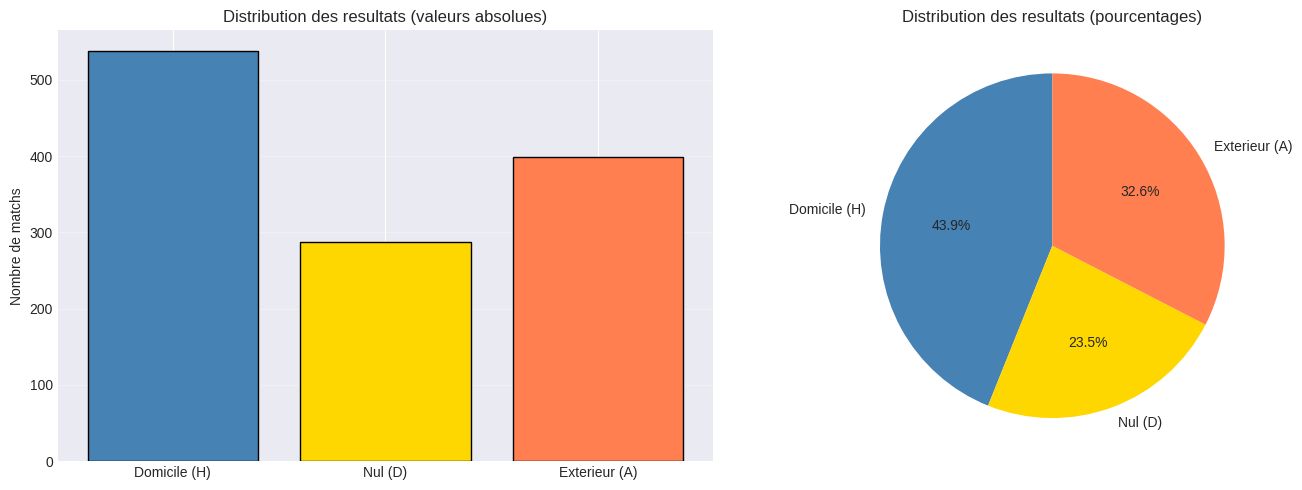

In [27]:
class_distribution = df['Result'].value_counts()
class_proportion   = df['Result'].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(['Domicile (H)','Nul (D)','Exterieur (A)'],
            [class_distribution['H'],class_distribution['D'],class_distribution['A']],
            color=['steelblue','gold','coral'], edgecolor='black')
axes[0].set_title('Distribution des resultats (valeurs absolues)')
axes[0].set_ylabel('Nombre de matchs')
axes[0].grid(axis='y', alpha=0.3)
axes[1].pie(
    [class_proportion['H'],class_proportion['D'],class_proportion['A']],
    labels=['Domicile (H)','Nul (D)','Exterieur (A)'],
    autopct='%1.1f%%', colors=['steelblue','gold','coral'], startangle=90
)
axes[1].set_title('Distribution des resultats (pourcentages)')
plt.tight_layout()
plt.show()

## 7. Comparaison SMOTE vs Sans SMOTE

Le **SMOTE** génère des exemples synthétiques pour équilibrer les classes.
On compare ici les deux approches sur toutes les métriques :
accuracy, precision, recall et f1-score par classe.

- **Precision** : quand le modèle prédit X, il a raison dans combien de cas ?
- **Recall** : parmi tous les vrais X, combien le modèle en a trouvé ?
- **F1-score** : équilibre entre precision et recall

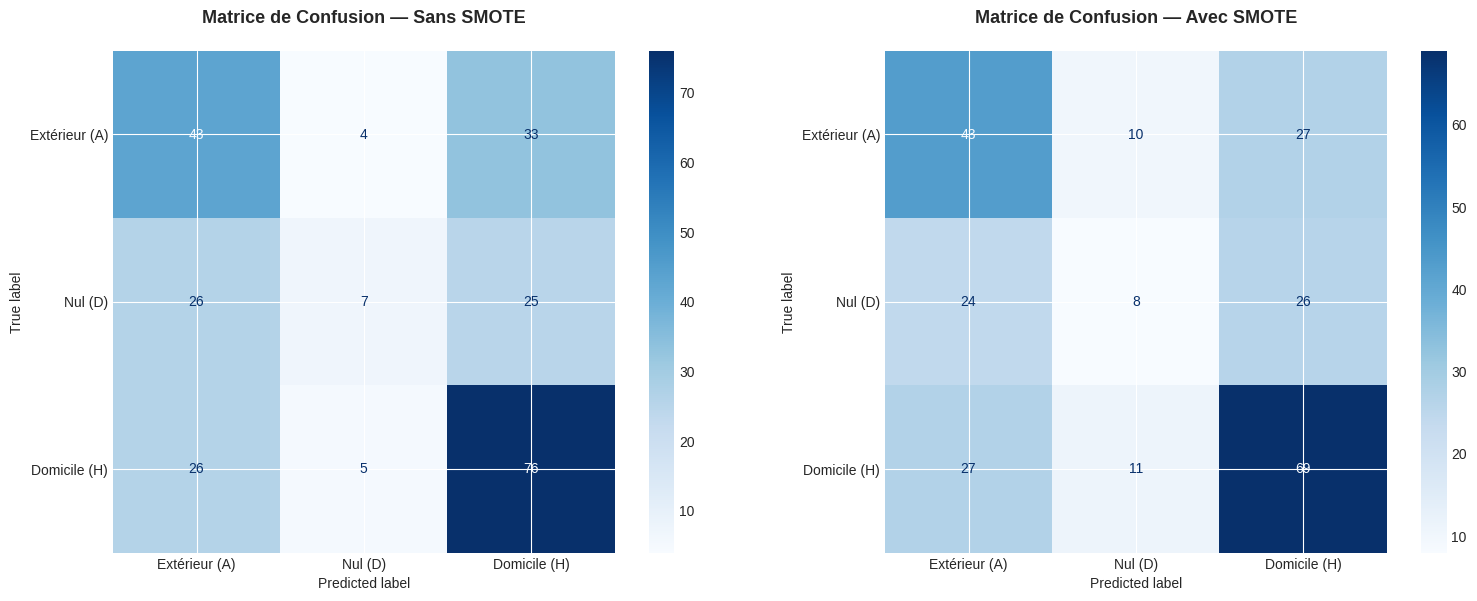

In [28]:
# Comparaison SMOTE vs Sans SMOTE
from sklearn.metrics import accuracy_score, classification_report

label_names = ['Extérieur (A)', 'Nul (D)', 'Domicile (H)']

# Modèle sans SMOTE
pipeline_no_smote = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(random_state=42, n_estimators=100))
])
pipeline_no_smote.fit(X2_train, y_train)
y_pred_no_smote = pipeline_no_smote.predict(X2_test)

# Modèle avec SMOTE
pipeline_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('classifier',   RandomForestClassifier(random_state=42, n_estimators=100))
])
pipeline_smote.fit(X2_train, y_train)
y_pred_smote = pipeline_smote.predict(X2_test)
# Matrices de confusion — Sans SMOTE vs Avec SMOTE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, titre in zip(
    axes,
    [y_pred_no_smote, y_pred_smote],
    ['Sans SMOTE', 'Avec SMOTE']
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names).plot(
        cmap='Blues', values_format='d', ax=ax)
    ax.set_title(f'Matrice de Confusion — {titre}\n', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# # Affichage comparatif
# for nom, y_pred in [('Sans SMOTE', y_pred_no_smote), ('Avec SMOTE', y_pred_smote)]:
#     print('=' * 55)
#     print(f'  {nom}')
#     print('=' * 55)
#     print(f'  Accuracy : {accuracy_score(y_test, y_pred):.2%}')
#     print()
#     print(classification_report(y_test, y_pred, target_names=label_names))

### Analyse des résultats — SMOTE vs Sans SMOTE

| Métrique            | Sans SMOTE | Avec SMOTE |
|---------------------|-----------|------------|
| Accuracy            | 51.43%    | 48.98%     |
| F1 Domicile (H)     | 0.63      | 0.60       |
| F1 Nul (D)          | 0.19      | 0.18       |
| F1 Extérieur (A)    | 0.49      | 0.49       |
| Recall Domicile (H) | 0.71      | 0.64       |
| Recall Nul (D)      | 0.12      | 0.14       |
| Recall Extérieur (A)| 0.54      | 0.54       |

O SMOTE **dégrade légèrement les performances** sur ce dataset.

Le recall des nuls passe de 0.12 à 0.14 — une légère amélioration,
mais au prix d'une perte sur les victoires à domicile (0.71 → 0.64)
et sur l'accuracy globale.

La raison est structurelle : les empates ne suivent pas de frontière
claire dans l'espace des features. Les exemples synthétiques générés
par le SMOTE n'apportent pas d'information réelle et introduisent du bruit.

## 8. Comparaison des algorithmes
Test de plusieurs algorithmes pour verifier si le RandomForest est le meilleur choix sur ce dataset.

Les modeles bases sur le boosting (GradientBoosting, XGBoost) peinent avec un petit dataset
car ils ont tendance a overfitter.

In [29]:
modeles = {
    'RandomForest':       RandomForestClassifier(random_state=42, n_estimators=100),
    'GradientBoosting':   GradientBoostingClassifier(random_state=42, n_estimators=100),
    'ExtraTrees':         ExtraTreesClassifier(random_state=42, n_estimators=100),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'XGBoost':            XGBClassifier(random_state=42, n_estimators=100, eval_metric='mlogloss'),
}

print('=' * 55)
print('  COMPARAISON DES ALGORITHMES')
print('=' * 55)
for nom, clf in modeles.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
    sc   = cross_val_score(pipe, X2, y_encoded, cv=5, scoring='accuracy')
    print(f'  {nom:<22} : {sc.mean():.2%} (+/-{sc.std():.2%})')

  COMPARAISON DES ALGORITHMES
  RandomForest           : 52.65% (+/-1.53%)
  GradientBoosting       : 48.24% (+/-2.61%)
  ExtraTrees             : 50.86% (+/-1.94%)
  LogisticRegression     : 51.84% (+/-2.16%)
  XGBoost                : 46.78% (+/-3.19%)


## 9. Optimisation des hyperparametres — GridSearchCV
Le `GridSearchCV` teste toutes les combinaisons de parametres en validation croisee
pour trouver la configuration optimale du RandomForest.

In [30]:
param_grid = {
    'classifier__n_estimators':      [50, 100, 200],
    'classifier__max_depth':         [5, 10, 15, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf':  [1, 2, 4],
}

pipeline_base = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(random_state=42)),
])

grid_search = GridSearchCV(pipeline_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X2_train, y_train)

print('\nMeilleurs hyperparametres :')
for param, value in grid_search.best_params_.items():
    print(f'  {param}: {value}')
print(f'\nMeilleur score (CV) : {grid_search.best_score_:.2%}')
print(f'Score sur le test   : {grid_search.score(X2_test, y_test):.2%}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Meilleurs hyperparametres :
  classifier__max_depth: 15
  classifier__min_samples_leaf: 4
  classifier__min_samples_split: 2
  classifier__n_estimators: 50

Meilleur score (CV) : 57.96%
Score sur le test   : 51.02%


## 10. Entraínement et sauvegarde du modele final
Le modele final est entraine sur **toutes les donnees** avec les meilleurs hyperparametres,
puis sauvegarde avec `joblib`.

In [31]:
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        n_estimators=50, max_depth=15,
        min_samples_split=4, min_samples_leaf=2,
        random_state=42
    ))
])

final_model.fit(X2, y_encoded)

model_filename = 'dataset/match_model_v1.joblib'
joblib.dump(final_model, model_filename)
print(f'Modele sauvegarde : {model_filename} ({os.path.getsize(model_filename)/1024:.1f} KB)')

Modele sauvegarde : dataset/match_model_v1.joblib (1375.9 KB)


## 11. Test du modele — Prediction d'un match
Cellule finale de test. Renseignez les equipes, la journee, la saison et l'arbitre
pour obtenir les probabilites de chaque resultat.

Les moyennes et classements sont recuperes automatiquement depuis le dataset.

In [ ]:
# Recuperation des donnees de reference
avg_goals_ref = df.groupby(['league.season','HomeTeam'])[
    ['home_avg_goals_scored','home_avg_goals_conceded']
].first().reset_index().rename(columns={
    'HomeTeam':               'Team',
    'home_avg_goals_scored':  'avg_goals_scored',
    'home_avg_goals_conceded':'avg_goals_conceded'
})

standings_ref = df.groupby(['league.season','HomeTeam'])[
    'home_season_rank'
].first().reset_index().rename(columns={
    'HomeTeam':        'Team',
    'home_season_rank':'season_rank'
})

def predict_match(home_team, away_team, round_num, season, referee):
    def get_stat(team, saison, col, source):
        try:    return source.set_index(['league.season','Team']).loc[(saison, team), col]
        except: return 0.0

    input_data = pd.DataFrame([{
        'HomeTeam':                home_team,
        'AwayTeam':                away_team,
        'Referee':                 referee,
        'league.season':           season,
        'Round':                   round_num,
        'home_avg_goals_scored':   get_stat(home_team, season, 'avg_goals_scored',   avg_goals_ref),
        'home_avg_goals_conceded': get_stat(home_team, season, 'avg_goals_conceded', avg_goals_ref),
        'home_season_rank':        get_stat(home_team, season, 'season_rank',         standings_ref),
        'away_avg_goals_scored':   get_stat(away_team, season, 'avg_goals_scored',   avg_goals_ref),
        'away_avg_goals_conceded': get_stat(away_team, season, 'avg_goals_conceded', avg_goals_ref),
        'away_season_rank':        get_stat(away_team, season, 'season_rank',         standings_ref),
    }])

    loaded_model  = joblib.load('dataset/match_model_v1.joblib')
    probabilities = loaded_model.predict_proba(input_data)[0]
    prediction    = loaded_model.predict(input_data)[0]
    label_names   = {0:'Exterieur (A)', 1:'Nul (D)', 2:'Domicile (H)'}

    print('=' * 50)
    print(f'  {home_team}  vs  {away_team}')
    print(f'  Journee {round_num} — Saison {season}/{season+1}')
    print(f'  Arbitre : {referee}')
    print('=' * 50)
    print('  Probabilites :')
    for idx, prob in enumerate(probabilities):
        marker = ' <-- predit' if idx == prediction else ''
        print(f'    {label_names[idx]:<20} : {prob:.1%}{marker}')
    print(f'\n  Resultat predit : {label_names[prediction]}')
    print('=' * 50)

# Exemple de prediction
predict_match(
    home_team = 'Paris SG',
    away_team = 'Marseille',
    round_num = 25,
    season    = 2024,
    referee   = 'W. Delajod',
)

: 